## Imports

In [23]:
from ctf4science.data_module import _load_test_data, load_dataset
from ctf4science.visualization_module import Visualization
import numpy as np
import matplotlib.pyplot as plt
import os
from pathlib import Path
import pickle

%matplotlib inline

## Load Pickle

In [24]:
if 0:
    fname = "PDE_KS_p8_v0_r20.pkl"
    with open(Path(os.getcwd()).parent / "models" / "chronos-forecasting" / "pickles" / fname, "rb") as f:
        pred_data = pickle.load(f)

    print(pred_data.shape)

## Make plot

In [25]:
dataset_name = "PDE_KS"
pair_id = 3

train_data_list, init_data = load_dataset(dataset_name, pair_id)
test_data = _load_test_data(dataset_name, pair_id)

print(f"Train matrices: {len(train_data_list)}, shapes: {[t.shape for t in train_data_list]}")
print(f"Test data shape: {test_data.shape}")
if init_data is not None:
    print(f"Init data shape: {init_data.shape}")

Train matrices: 1, shapes: [(10000, 1024)]
Test data shape: (1000, 1024)


## Plot Train Data

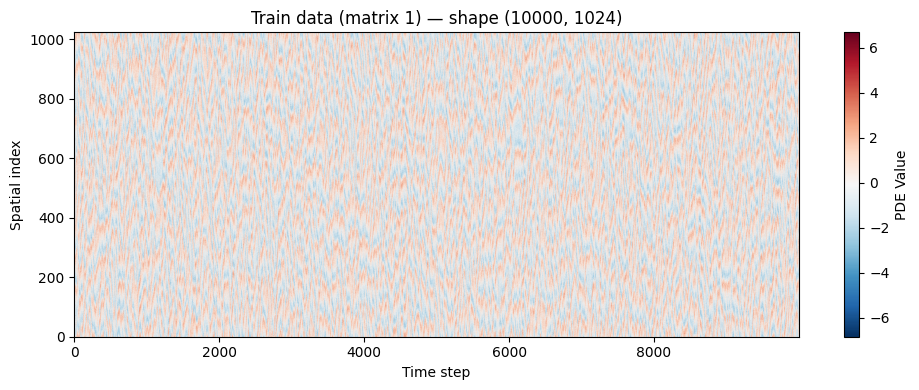

In [26]:
for i, train_data in enumerate(train_data_list):
    fig, ax = plt.subplots(figsize=(10, 4))
    im = ax.imshow(train_data.T, aspect="auto", origin="lower", cmap="RdBu_r")
    ax.set_xlabel("Time step")
    ax.set_ylabel("Spatial index")
    ax.set_title(f"Train data (matrix {i+1}) — shape {train_data.shape}")
    plt.colorbar(im, ax=ax, label="PDE Value")
    plt.tight_layout()
    plt.show()

## Plot Test Data

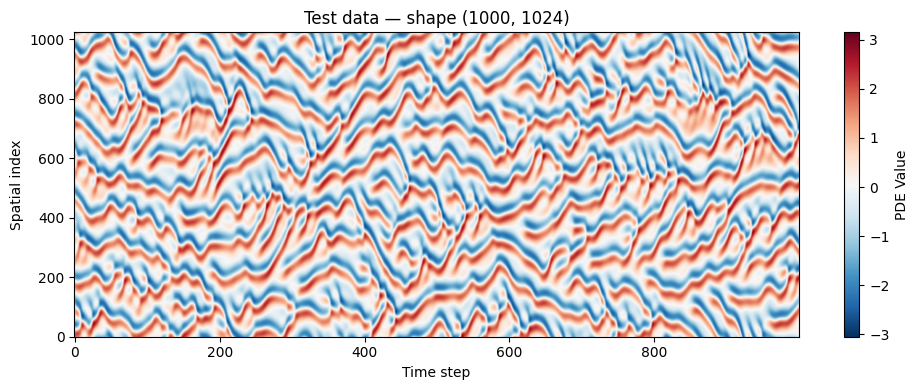

In [27]:
fig, ax = plt.subplots(figsize=(10, 4))
im = ax.imshow(test_data.T, aspect="auto", origin="lower", cmap="RdBu_r")
ax.set_xlabel("Time step")
ax.set_ylabel("Spatial index")
ax.set_title(f"Test data — shape {test_data.shape}")
plt.colorbar(im, ax=ax, label="PDE Value")
plt.tight_layout()
plt.show()

## Side-by-side Train vs Test Comparison

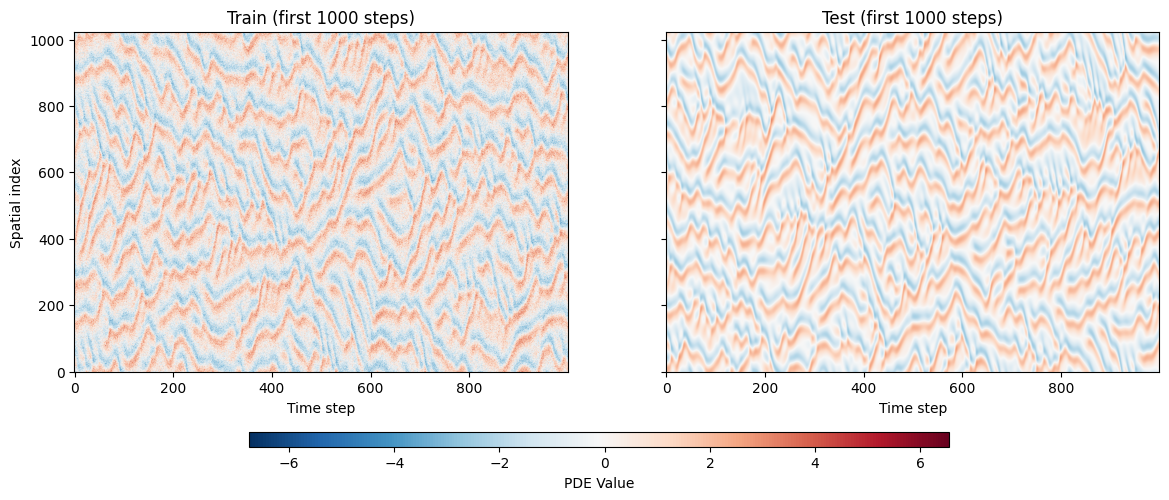

In [32]:
train_data = train_data_list[0]

n_rows = min(test_data.shape[0], train_data.shape[0])
vmin = min(train_data[:n_rows].min(), test_data[:n_rows].min())
vmax = max(train_data[:n_rows].max(), test_data[:n_rows].max())

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

im0 = axes[0].imshow(train_data[:n_rows].T, aspect="auto", origin="lower", cmap="RdBu_r", vmin=vmin, vmax=vmax)
axes[0].set_xlabel("Time step")
axes[0].set_ylabel("Spatial index")
axes[0].set_title(f"Train (first {n_rows} steps)")

im1 = axes[1].imshow(test_data[:n_rows].T, aspect="auto", origin="lower", cmap="RdBu_r", vmin=vmin, vmax=vmax)
axes[1].set_xlabel("Time step")
axes[1].set_title(f"Test (first {n_rows} steps)")

fig.subplots_adjust(bottom=0.2)
cbar_ax = fig.add_axes([0.25, 0.05, 0.5, 0.03])
fig.colorbar(im1, cax=cbar_ax, orientation="horizontal", label="PDE Value")
plt.show()